# `apply` vs `apply_peetre`: Efficiency & Precision Analysis (Extended)

This notebook compares **six** ways of applying a pseudo-differential operator
through the Peetre decomposition pipeline, now covering all joint-residual backends:

| label | `backend` | `joint_backend` | meaning |
|---|---|---|---|
| `direct` | `"direct"` | — | ground truth: full direct quadrature |
| `peetre (joint=direct)` | `"peetre"` | `"direct"` | fast FFT for local/separable; direct quadrature for joint residual |
| `peetre (joint=lowrank)` | `"peetre"` | `"lowrank"` | Chebyshev/SVD separable factorization of the joint residual |
| `peetre (joint=nufft)` | `"peetre"` | `"nufft"` | NUFFT phase decomposition for oscillatory joint symbols |
| `peetre (joint=aaa)` | `"peetre"` | `"aaa"` | Vector-valued AAA rational fit for pole/resolvent-shaped joint symbols |
| `peetre (joint=auto)` | `"peetre"` | `"auto"` | symbolic auto-selection: routes to nufft / aaa / lowrank per structure |

We also benchmark `apply_hybrid()`, which splits the joint residual into
additive terms and routes **each term** to its optimal backend — the key
advantage for mixed symbols where monolithic `auto` falls back to `direct`.

**Boundary condition**: `periodic` throughout (NUFFT requires it; all other
backends work with both periodic and dirichlet).


### 🐛 Bug Fix Note: The Frequency Grid Misalignment

If you previously ran this with `np.fft.fftshift` applied to `kx` and `ky`,
you likely saw massive errors (e.g., `1.46e+04`) for Variable Coefficients,
while Constant Coefficients had `0.00e+00` error.

**Why?** The slow path in `apply()` correctly recomputes frequencies internally.
But the fast path `_apply_constant_fft()` (used by `apply_peetre()` for the
separated $q(\xi)$ multipliers) blindly uses the `kx` array passed to it.
Passing a **shifted** `kx` multiplied the unshifted FFT spectrum by the shifted
symbol, completely misaligning the frequencies.

**The Fix:** We simply use the **unshifted** `fftfreq` grid below so it perfectly
matches the `scipy.fft.fft` convention.


In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
from psiop import PseudoDifferentialOperator

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

boundary_condition = 'periodic'  # NUFFT requires periodic


## Benchmark harness

`benchmark_configs` runs a list of `apply()` configurations on the same field `u`
and returns, for each configuration, the mean execution time over `repeats` calls
and the relative $L^2$ error against the **first** configuration in the list
(`backend="direct"`), which is treated as ground truth.

The six configurations used throughout are:

| label | `backend` | `joint_backend` | meaning |
|---|---|---|---|
| `direct` | `"direct"` | — | ground truth: full direct quadrature |
| `peetre (joint=direct)` | `"peetre"` | `"direct"` | fast FFT for local/separable, direct for joint |
| `peetre (joint=lowrank)` | `"peetre"` | `"lowrank"` | Chebyshev/SVD pairs for joint |
| `peetre (joint=nufft)` | `"peetre"` | `"nufft"` | NUFFT phase decomposition |
| `peetre (joint=aaa)` | `"peetre"` | `"aaa"` | AAA rational fit |
| `peetre (joint=auto)` | `"peetre"` | `"auto"` | symbolic auto-dispatch |

A separate `benchmark_hybrid` function compares `apply(joint_backend='auto')`
against `apply_hybrid()` for mixed-structure symbols.


In [2]:
CONFIGS = [
    {'label': 'direct',                 'kwargs': dict(backend='direct')},
    {'label': 'peetre (joint=direct)',  'kwargs': dict(backend='peetre', joint_backend='direct')},
    {'label': 'peetre (joint=lowrank)', 'kwargs': dict(backend='peetre', joint_backend='lowrank')},
    {'label': 'peetre (joint=nufft)',   'kwargs': dict(backend='peetre', joint_backend='nufft')},
    {'label': 'peetre (joint=aaa)',     'kwargs': dict(backend='peetre', joint_backend='aaa')},
    {'label': 'peetre (joint=auto)',    'kwargs': dict(backend='peetre', joint_backend='auto')},
]

# Lighter config set for local/separable-only symbols (no joint residual)
CONFIGS_NO_JOINT = CONFIGS[:3]


def make_test_function(op, x_grid, y_grid=None):
    """Same test function u as in the baseline efficiency analysis."""
    if op.dim == 1:
        return np.exp(-x_grid**2) * np.cos(5 * x_grid)
    X, Y = np.meshgrid(x_grid, y_grid, indexing='ij')
    return np.exp(-(X**2 + Y**2)) * np.cos(5 * X) * np.cos(5 * Y)


def benchmark_configs(op, u, x_grid, kx, y_grid=None, ky=None, configs=CONFIGS,
                      repeats=3, boundary_condition='periodic'):
    """
    Run each configuration in `configs` on `op.apply(u, ...)`, timing it and
    computing its relative L2 error against the first configuration's output
    (assumed to be backend='direct', i.e. ground truth).

    Returns
    -------
    dict: label -> {'mean_time': float, 'times': list[float], 'rel_l2_error': float}
    """
    results = {}
    ref = None

    for cfg in configs:
        label, kwargs = cfg['label'], cfg['kwargs']

        # Warm-up call (JIT / cache effects, symbolic decomposition caching, etc.)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            op.apply(u, x_grid, kx, y_grid=y_grid, ky=ky,
                     boundary_condition=boundary_condition, **kwargs)

        times = []
        out = None
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            for _ in range(repeats):
                t0 = time.perf_counter()
                out = op.apply(u, x_grid, kx, y_grid=y_grid, ky=ky,
                               boundary_condition=boundary_condition, **kwargs)
                times.append(time.perf_counter() - t0)

        mean_t = float(np.mean(times))

        if ref is None:
            ref = out
            err = 0.0
        else:
            norm_ref = np.linalg.norm(ref)
            err = float(np.linalg.norm(out - ref) / norm_ref) if norm_ref > 0 else float(np.linalg.norm(out - ref))

        results[label] = {'mean_time': mean_t, 'times': times, 'rel_l2_error': err}

    return results


def benchmark_hybrid(op, u, x_grid, kx, y_grid=None, ky=None,
                     repeats=3, boundary_condition='periodic'):
    """
    Compare monolithic auto vs apply_hybrid for mixed-structure symbols.

    Returns
    -------
    dict with keys 'monolithic' and 'hybrid', each containing
    {'mean_time', 'rel_l2_error'} relative to direct ground truth.
    """
    # Ground truth
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        ref = op.apply(u, x_grid, kx, y_grid=y_grid, ky=ky,
                       boundary_condition=boundary_condition,
                       backend='direct')

    results = {}
    for label, fn in [
        ('monolithic (auto)', lambda: op.apply(
            u, x_grid, kx, y_grid=y_grid, ky=ky,
            boundary_condition=boundary_condition,
            backend='peetre', joint_backend='auto')),
        ('hybrid', lambda: op.apply_hybrid(
            u, x_grid, kx, y_grid=y_grid, ky=ky,
            boundary_condition=boundary_condition)),
    ]:
        # Warm-up
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            fn()

        times = []
        out = None
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            for _ in range(repeats):
                t0 = time.perf_counter()
                out = fn()
                times.append(time.perf_counter() - t0)

        norm_ref = np.linalg.norm(ref)
        err = float(np.linalg.norm(out - ref) / norm_ref) if norm_ref > 0 else 0.0
        results[label] = {
            'mean_time': float(np.mean(times)),
            'rel_l2_error': err,
        }
    return results


## 1D Symbols

We keep the original local/non-local symbols and extend the joint set with
**oscillatory** symbols that exercise the NUFFT backend:

| Symbol | Class | Best backend |
|---|---|---|
| `exp(−(xξ)²/40000)` | Joint (Smooth) | `lowrank` |
| `1/(1+x²+ξ²)` | Joint (Resolvent) | `aaa` |
| `ξ² + 1/(1+x²+ξ²)` | Joint (Mixed local+resolvent) | `aaa` for residual |
| `sin(x·ξ)` | Joint (Oscillatory) | `nufft` |
| `x² · exp(i·x·ξ) · cos(ξ)` | Joint (Chirp) | `nufft` |
| `sin(xξ) + 1/(1+(x−ξ)²) + exp(−(x−ξ)²/8)` | Joint (All three) | `hybrid` |


In [3]:
# 1D Symbols
x, xi = sp.symbols('x xi', real=True)

sym_1d_loc_c   = xi**2
sym_1d_loc_v   = (1 + 0.5 * sp.sin(x)) * xi**2
sym_1d_nloc_c  = sp.sqrt(xi**2 + 1.0)
sym_1d_nloc_v  = (1 + 0.5 * sp.sin(x)) * sp.sqrt(xi**2 + 1.0)

# Joint symbols: entangled in x and xi, cannot be separated into a(x) * q(xi)
sym_1d_joint_smooth    = sp.exp(-(x * xi)**2 / 40000)
sym_1d_joint_resolvent = 1 / (1 + x**2 + xi**2)
sym_1d_joint_mixed     = xi**2 + 1 / (1 + x**2 + xi**2)

# NEW: oscillatory symbols for NUFFT
sym_1d_joint_osc       = sp.sin(x * xi)
sym_1d_joint_chirp     = x**2 * sp.exp(sp.I * x * xi) * sp.cos(xi)

# NEW: mixed-structure symbol (all three backend classes)
sym_1d_joint_allthree  = (sp.sin(x * xi)
                          + 1 / (1 + (x - xi)**2)
                          + sp.exp(-((x - xi)**2) / 8))

ops_1d = {
    '1D Local (Const)':       PseudoDifferentialOperator(sym_1d_loc_c, [x], mode='symbol'),
    '1D Local (Var)':         PseudoDifferentialOperator(sym_1d_loc_v, [x], mode='symbol'),
    '1D Non-Local (Const)':   PseudoDifferentialOperator(sym_1d_nloc_c, [x], mode='symbol'),
    '1D Non-Local (Var)':     PseudoDifferentialOperator(sym_1d_nloc_v, [x], mode='symbol'),
    '1D Joint (Smooth)':      PseudoDifferentialOperator(sym_1d_joint_smooth, [x], mode='symbol'),
    '1D Joint (Resolvent)':   PseudoDifferentialOperator(sym_1d_joint_resolvent, [x], mode='symbol'),
    '1D Joint (Mixed)':       PseudoDifferentialOperator(sym_1d_joint_mixed, [x], mode='symbol'),
    '1D Joint (Oscillatory)': PseudoDifferentialOperator(sym_1d_joint_osc, [x], mode='symbol'),
    '1D Joint (Chirp)':       PseudoDifferentialOperator(sym_1d_joint_chirp, [x], mode='symbol'),
    '1D Joint (AllThree)':    PseudoDifferentialOperator(sym_1d_joint_allthree, [x], mode='symbol'),
}


In [6]:
# N_values_1d = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
N_values_1d = [16, 32, 64, 128, 256, 512]

# Symbols with no joint residual: only need the original 3 configs
_no_joint_names = {
    '1D Local (Const)', '1D Local (Var)',
    '1D Non-Local (Const)', '1D Non-Local (Var)',
}

rows_1d = []

print('Running 1D Benchmarks...')
for N in N_values_1d:
    L = 10
    dx = L / N
    x_grid = -L/2 + dx * np.arange(N)

    # Unshifted frequencies to match scipy.fft.fft output convention
    kx = 2 * np.pi * np.fft.fftfreq(N, d=dx)

    for name, op in ops_1d.items():
        u = make_test_function(op, x_grid)
        cfgs = CONFIGS_NO_JOINT if name in _no_joint_names else CONFIGS
        res = benchmark_configs(op, u, x_grid, kx, repeats=4,
                                boundary_condition=boundary_condition,
                                configs=cfgs)

        t_direct = res['direct']['mean_time']

        for label, r in res.items():
            speedup = t_direct / r['mean_time'] if r['mean_time'] > 0 else np.nan
            rows_1d.append(dict(
                N=N, symbol=name, backend=label,
                time=r['mean_time'], speedup=speedup, err=r['rel_l2_error']
            ))
            print(f"N={N:5d} | {name:24s} | {label:24s} | "
                  f"time: {r['mean_time']:.4f}s | err: {r['rel_l2_error']:.2e}")

df_1d = pd.DataFrame(rows_1d)


Running 1D Benchmarks...
N=   16 | 1D Local (Const)         | direct                   | time: 0.0002s | err: 0.00e+00
N=   16 | 1D Local (Const)         | peetre (joint=direct)    | time: 0.0007s | err: 0.00e+00
N=   16 | 1D Local (Const)         | peetre (joint=lowrank)   | time: 0.0007s | err: 0.00e+00
N=   16 | 1D Local (Var)           | direct                   | time: 0.0011s | err: 0.00e+00
N=   16 | 1D Local (Var)           | peetre (joint=direct)    | time: 0.0010s | err: 9.23e-16
N=   16 | 1D Local (Var)           | peetre (joint=lowrank)   | time: 0.0009s | err: 9.23e-16
N=   16 | 1D Non-Local (Const)     | direct                   | time: 0.0001s | err: 0.00e+00
N=   16 | 1D Non-Local (Const)     | peetre (joint=direct)    | time: 0.0009s | err: 0.00e+00
N=   16 | 1D Non-Local (Const)     | peetre (joint=lowrank)   | time: 0.0009s | err: 0.00e+00
N=   16 | 1D Non-Local (Var)       | direct                   | time: 0.0011s | err: 0.00e+00
N=   16 | 1D Non-Local (Var)       

### 1D Results Table


In [7]:
pivot_time_1d = df_1d.pivot_table(index=['symbol', 'N'], columns='backend', values='time')
pivot_err_1d  = df_1d.pivot_table(index=['symbol', 'N'], columns='backend', values='err')
pivot_speedup_1d = df_1d.pivot_table(index=['symbol', 'N'], columns='backend', values='speedup')

display(pivot_time_1d)
display(pivot_err_1d)
display(pivot_speedup_1d)


backend                       direct  peetre (joint=aaa)  peetre (joint=auto)  \
symbol                 N                                                        
1D Joint (AllThree)    16   0.002365            0.568922             0.571385   
                       32   0.001901            0.544645             0.535293   
                       64   0.005993            0.624089             0.585433   
                       128  0.003989            0.562192             0.566045   
                       256  0.006126            0.566134             0.563821   
                       512  0.020157            0.616824             0.618984   
1D Joint (Chirp)       16   0.001197            0.040257             0.091960   
                       32   0.000944            0.104367             0.086013   
                       64   0.004991            0.020792             0.056020   
                       128  0.005989            0.020688             0.060652   
                       256  0.007912            0.028517             0.152902   
                       512  0.021785            0.043138             0.261969   
1D Joint (Mixed)       16   0.001178            0.025667             0.024552   
                       32   0.001081            0.093226             0.091908   
                       64   0.001475            0.379580             0.381302   
                       128  0.001871            0.003740             0.004705   
                       256  0.004233            0.005821             0.006775   
                       512  0.011239            0.013225             0.015794   
1D Joint (Oscillatory) 16   0.000742            0.028209             0.103041   
                       32   0.000665            0.097989             0.078804   
                       64   0.000982            0.005357             0.048954   
                       128  0.001613            0.006120             0.047941   
                       256  0.004599            0.009170             0.162132   
                       512  0.015963            0.020498             0.247865   
1D Joint (Resolvent)   16   0.001055            0.024666             0.024375   
                       32   0.000842            0.093415             0.093342   
                       64   0.001247            0.381365             0.379665   
                       128  0.001783            0.002817             0.006020   
                       256  0.003477            0.004107             0.006327   
                       512  0.012939            0.013945             0.014766   
1D Joint (Smooth)      16   0.000705            0.023995             0.004997   
                       32   0.000816            0.091263             0.008685   
                       64   0.001022            0.379875             0.013033   
                       128  0.001432            1.447055             0.017027   
                       256  0.003343            5.726339             0.016602   
                       512  0.014851           23.473255             0.020391   
1D Local (Const)       16   0.000166                 NaN                  NaN   
                       32   0.000194                 NaN                  NaN   
                       64   0.000068                 NaN                  NaN   
                       128  0.000083                 NaN                  NaN   
                       256  0.000093                 NaN                  NaN   
                       512  0.000125                 NaN                  NaN   
1D Local (Var)         16   0.001109                 NaN                  NaN   
                       32   0.000947                 NaN                  NaN   
                       64   0.001277                 NaN                  NaN   
                       128  0.001722                 NaN                  NaN   
                       256  0.003927                 NaN                  NaN   
                       512  0.0

backend                     direct  peetre (joint=aaa)  peetre (joint=auto)  \
symbol                 N                                                      
1D Joint (AllThree)    16      0.0        1.414640e-02         1.414640e-02   
                       32      0.0        3.075506e-16         3.075506e-16   
                       64      0.0        3.417238e-16         3.417238e-16   
                       128     0.0        2.759455e-16         2.759455e-16   
                       256     0.0        2.485312e-16         2.485312e-16   
                       512     0.0        2.553530e-16         2.553530e-16   
1D Joint (Chirp)       16      0.0        5.580451e-03         2.355091e-12   
                       32      0.0        1.657187e-01         1.308742e-12   
                       64      0.0        0.000000e+00         1.369712e-12   
                       128     0.0        0.000000e+00         1.518208e-12   
                       256     0.0        0.000000e+00         1.664596e-12   
                       512     0.0        0.000000e+00         1.725274e-12   
1D Joint (Mixed)       16      0.0        6.065737e-07         6.065737e-07   
                       32      0.0        5.377911e-07         5.377911e-07   
                       64      0.0        5.420735e-07         5.420735e-07   
                       128     0.0        5.817220e-15         5.817220e-15   
                       256     0.0        1.705940e-14         1.705940e-14   
                       512     0.0        5.658731e-15         5.658731e-15   
1D Joint (Oscillatory) 16      0.0        1.493971e-02         5.232385e-13   
                       32      0.0        3.059600e-01         1.291493e-12   
                       64      0.0        0.000000e+00         1.299742e-12   
                       128     0.0        0.000000e+00         1.084899e-12   
                       256     0.0        0.000000e+00         1.129364e-12   
                       512     0.0        0.000000e+00         1.089593e-12   
1D Joint (Resolvent)   16      0.0        9.080549e-05         9.080549e-05   
                       32      0.0        2.578826e-04         2.578826e-04   
                       64      0.0        3.076384e-04         3.076384e-04   
                       128     0.0        0.000000e+00         0.000000e+00   
                       256     0.0        0.000000e+00         0.000000e+00   
                       512     0.0        0.000000e+00         0.000000e+00   
1D Joint (Smooth)      16      0.0        1.046246e-06         3.016096e-06   
                       32      0.0        1.609469e-08         3.332030e-07   
                       64      0.0        4.777590e-07         3.678358e-06   
                       128     0.0        4.212069e-09         4.276880e-07   
                       256     0.0        1.313658e-06         2.361503e-06   
                       512     0.0        4.390725e-07         3.156872e-05   
1D Local (Const)       16      0.0                 NaN                  NaN   
                       32      0.0                 NaN                  NaN   
                       64      0.0                 NaN                  NaN   
                       128     0.0                 NaN                  NaN   
                       256     0.0                 NaN                  NaN   
                       512     0.0                 NaN                  NaN   
1D Local (Var)         16      0.0                 NaN                  NaN   
                       32      0.0                 NaN                  NaN   
                       64      0.0                 NaN                  NaN   
                       128     0.0                 NaN                  NaN   
                       256     0.0                 NaN                  NaN   
                       512     0.0                 NaN                  NaN   
1D Non-Local (Const)   16      0.0                

backend                     direct  peetre (joint=aaa)  peetre (joint=auto)  \
symbol                 N                                                      
1D Joint (AllThree)    16      1.0            0.004157             0.004139   
                       32      1.0            0.003490             0.003550   
                       64      1.0            0.009604             0.010238   
                       128     1.0            0.007096             0.007048   
                       256     1.0            0.010821             0.010865   
                       512     1.0            0.032679             0.032565   
1D Joint (Chirp)       16      1.0            0.029730             0.013015   
                       32      1.0            0.009043             0.010973   
                       64      1.0            0.240023             0.089086   
                       128     1.0            0.289500             0.098747   
                       256     1.0            0.277429             0.051743   
                       512     1.0            0.504994             0.083158   
1D Joint (Mixed)       16      1.0            0.045880             0.047963   
                       32      1.0            0.011598             0.011764   
                       64      1.0            0.003886             0.003869   
                       128     1.0            0.500226             0.397590   
                       256     1.0            0.727147             0.624751   
                       512     1.0            0.849786             0.711562   
1D Joint (Oscillatory) 16      1.0            0.026321             0.007206   
                       32      1.0            0.006786             0.008438   
                       64      1.0            0.183295             0.020058   
                       128     1.0            0.263608             0.033653   
                       256     1.0            0.501523             0.028364   
                       512     1.0            0.778740             0.064400   
1D Joint (Resolvent)   16      1.0            0.042755             0.043265   
                       32      1.0            0.009014             0.009021   
                       64      1.0            0.003271             0.003285   
                       128     1.0            0.633041             0.296232   
                       256     1.0            0.846390             0.549473   
                       512     1.0            0.927888             0.876291   
1D Joint (Smooth)      16      1.0            0.029391             0.141125   
                       32      1.0            0.008939             0.093932   
                       64      1.0            0.002691             0.078433   
                       128     1.0            0.000989             0.084070   
                       256     1.0            0.000584             0.201378   
                       512     1.0            0.000633             0.728320   
1D Local (Const)       16      1.0                 NaN                  NaN   
                       32      1.0                 NaN                  NaN   
                       64      1.0                 NaN                  NaN   
                       128     1.0                 NaN                  NaN   
                       256     1.0                 NaN                  NaN   
                       512     1.0                 NaN                  NaN   
1D Local (Var)         16      1.0                 NaN                  NaN   
                       32      1.0                 NaN                  NaN   
                       64      1.0                 NaN                  NaN   
                       128     1.0                 NaN                  NaN   
                       256     1.0                 NaN                  NaN   
                       512     1.0                 NaN                  NaN   
1D Non-Local (Const)   16      1.0                

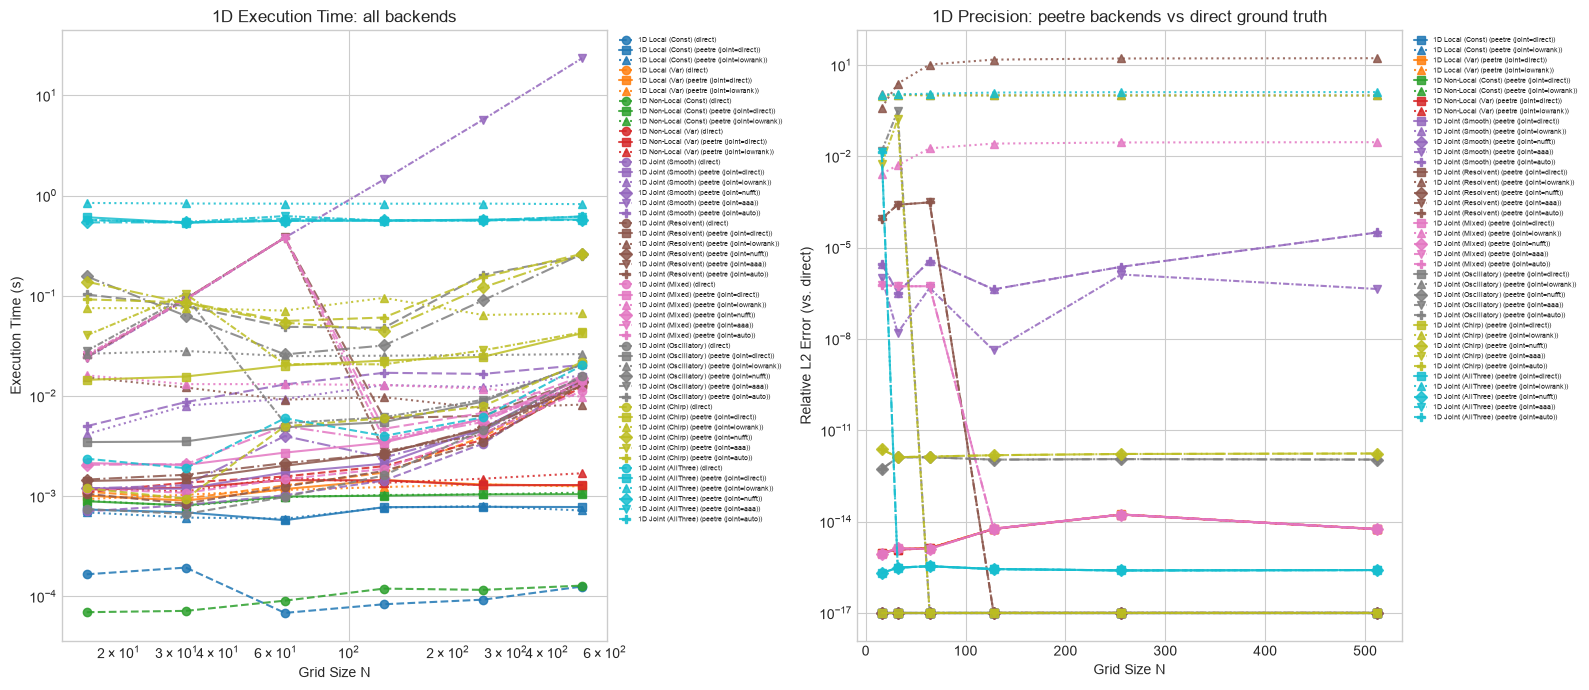

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

names_1d = list(ops_1d.keys())
cmap = plt.get_cmap('tab10')
colors_1d = {name: cmap(i % 10) for i, name in enumerate(names_1d)}

all_labels = [c['label'] for c in CONFIGS]
linestyles = {l: ['--', '-', ':', '-.', (0, (3, 1, 1, 1)), (0, (5, 2))][i]
              for i, l in enumerate(all_labels)}
markers    = {l: ['o', 's', '^', 'D', 'v', 'P'][i]
              for i, l in enumerate(all_labels)}

for name in names_1d:
    sub = df_1d[df_1d['symbol'] == name]
    for label in all_labels:
        s = sub[sub['backend'] == label].sort_values('N')
        if len(s) == 0:
            continue
        ax1.loglog(s['N'], s['time'], marker=markers[label],
                   linestyle=linestyles[label],
                   color=colors_1d[name], label=f'{name} ({label})', alpha=0.85)

ax1.set_xlabel('Grid Size N')
ax1.set_ylabel('Execution Time (s)')
ax1.set_title('1D Execution Time: all backends')
ax1.legend(fontsize=5, ncol=1, loc='upper left', bbox_to_anchor=(1.01, 1.0))

for name in names_1d:
    sub = df_1d[df_1d['symbol'] == name]
    for label in all_labels[1:]:  # skip 'direct' (err=0)
        s = sub[sub['backend'] == label].sort_values('N')
        if len(s) == 0:
            continue
        ax2.semilogy(s['N'], s['err'].clip(lower=1e-17), marker=markers[label],
                     linestyle=linestyles[label], color=colors_1d[name],
                     label=f'{name} ({label})', alpha=0.85)

ax2.set_xlabel('Grid Size N')
ax2.set_ylabel('Relative L2 Error (vs. direct)')
ax2.set_title('1D Precision: peetre backends vs direct ground truth')
ax2.legend(fontsize=5, ncol=1, loc='upper left', bbox_to_anchor=(1.01, 1.0))

plt.tight_layout()
plt.show()


---
## Backend Classification via `classify_joint=True`

`peetre_decomposition(classify_joint=True)` runs the symbolic auto-selector
at decomposition time and stores the recommended backend in
`deco['joint_backend']`. This is purely symbolic — no grid, no bounds.

The table below shows which backend the auto-selector recommends for each
1D joint symbol.


In [9]:
print(f"{'Symbol':<28s} {'Recommended backend':<20s}")
print('-' * 50)
for name, op in ops_1d.items():
    deco = op.peetre_decomposition(classify_joint=True)
    jb = deco.get('joint_backend', '— (no joint residual)')
    print(f"{name:<28s} {jb:<20s}")


Symbol                       Recommended backend 
--------------------------------------------------
1D Local (Const)             — (no joint residual)
1D Local (Var)               — (no joint residual)
1D Non-Local (Const)         — (no joint residual)
1D Non-Local (Var)           — (no joint residual)
1D Joint (Smooth)            lowrank             
1D Joint (Resolvent)         aaa                 
1D Joint (Mixed)             aaa                 
1D Joint (Oscillatory)       nufft               
1D Joint (Chirp)             nufft               
1D Joint (AllThree)          aaa                 


---
## Joint Backend Deep-Dive (1D)

For each structural class of joint symbol, we compare the applicable
backends head-to-head at a fixed grid size. This isolates the
approximation quality and speed of each backend on its target class.

| Symbol class | Backends compared |
|---|---|
| Oscillatory (`sin(xξ)`) | direct, nufft, lowrank, auto |
| Resolvent (`1/(1+x²+ξ²)`) | direct, aaa, lowrank, auto |
| Smooth Gaussian (`exp(−(xξ)²/40000)`) | direct, lowrank, aaa, auto |
| Chirp (`x²·exp(ixξ)·cos(ξ)`) | direct, nufft, auto |


In [10]:
N_dd = 512
L_dd = 10
dx_dd = L_dd / N_dd
x_dd = -L_dd/2 + dx_dd * np.arange(N_dd)
kx_dd = 2 * np.pi * np.fft.fftfreq(N_dd, d=dx_dd)
u_dd = make_test_function(ops_1d['1D Joint (Smooth)'], x_dd)

deepdive_symbols = {
    'Oscillatory':  (sym_1d_joint_osc,       ['direct', 'nufft', 'lowrank', 'auto']),
    'Resolvent':    (sym_1d_joint_resolvent,  ['direct', 'aaa', 'lowrank', 'auto']),
    'Smooth':       (sym_1d_joint_smooth,     ['direct', 'lowrank', 'aaa', 'auto']),
    'Chirp':        (sym_1d_joint_chirp,      ['direct', 'nufft', 'auto']),
}

print(f"{'Class':<14s} {'Backend':<12s} {'Time (s)':>10s} {'Rel L2 err':>12s}")
print('=' * 52)

dd_rows = []
for cls_name, (sym_expr, backends) in deepdive_symbols.items():
    op_dd = PseudoDifferentialOperator(sym_expr, [x], mode='symbol')
    cfgs = [{'label': 'direct', 'kwargs': dict(backend='direct')}]
    for jb in backends[1:]:
        cfgs.append({'label': jb, 'kwargs': dict(backend='peetre', joint_backend=jb)})

    res = benchmark_configs(op_dd, u_dd, x_dd, kx_dd, configs=cfgs,
                            repeats=3, boundary_condition=boundary_condition)
    for label, r in res.items():
        print(f"{cls_name:<14s} {label:<12s} {r['mean_time']:>10.4f} {r['rel_l2_error']:>12.3e}")
        dd_rows.append(dict(cls=cls_name, backend=label,
                            time=r['mean_time'], err=r['rel_l2_error']))
    print()

df_dd = pd.DataFrame(dd_rows)


Class          Backend        Time (s)   Rel L2 err
Oscillatory    direct           0.0179    0.000e+00
Oscillatory    nufft            0.3810    1.090e-12
Oscillatory    lowrank          0.0850    1.004e+00
Oscillatory    auto             0.3143    1.090e-12

Resolvent      direct           0.0140    0.000e+00
Resolvent      aaa              0.0177    0.000e+00
Resolvent      lowrank          0.0088    1.681e+01
Resolvent      auto             0.0176    0.000e+00

Smooth         direct           0.0186    0.000e+00
Smooth         lowrank          0.0190    3.157e-05
Smooth         aaa             25.8766    4.391e-07
Smooth         auto             0.0220    3.157e-05

Chirp          direct           0.0204    0.000e+00
Chirp          nufft            0.2757    1.725e-12
Chirp          auto             0.2625    1.725e-12



---
## Hybrid vs Monolithic Auto-Routing (1D)

For the mixed-structure symbol
`sin(xξ) + 1/(1+(x−ξ)²) + exp(−(x−ξ)²/8)`,
monolithic `joint_backend='auto'` sees the **sum** and cannot find a single
global pattern — it falls back to `direct` O(N²) quadrature.

`apply_hybrid()` splits the joint residual into additive terms and routes
each one to its optimal backend (NUFFT, AAA, lowrank), preserving the
O(N log N) speedup.


In [11]:
N_hyb = 512
L_hyb = 10
dx_hyb = L_hyb / N_hyb
x_hyb = -L_hyb/2 + dx_hyb * np.arange(N_hyb)
kx_hyb = 2 * np.pi * np.fft.fftfreq(N_hyb, d=dx_hyb)
u_hyb = make_test_function(ops_1d['1D Joint (AllThree)'], x_hyb)

op_hyb = ops_1d['1D Joint (AllThree)']

print(f"{'Backend':<22s} {'Time (s)':>10s} {'Rel L2 err':>12s}")
print('=' * 48)

hyb_res = benchmark_hybrid(op_hyb, u_hyb, x_hyb, kx_hyb,
                           repeats=3, boundary_condition=boundary_condition)
for label, r in hyb_res.items():
    print(f"{label:<22s} {r['mean_time']:>10.4f} {r['rel_l2_error']:>12.3e}")

# Also show direct for reference
t0 = time.perf_counter()
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    _ = op_hyb.apply(u_hyb, x_hyb, kx_hyb,
                     boundary_condition=boundary_condition, backend='direct')
t_dir = time.perf_counter() - t0
print(f"{'direct (reference)':<22s} {t_dir:>10.4f} {'0.000e+00':>12s}")


Backend                  Time (s)   Rel L2 err
monolithic (auto)          0.5772    2.554e-16
hybrid                     7.9378    2.554e-16
direct (reference)         0.0245    0.000e+00


## 2D Symbols

Same structure as 1D, with genuinely joint 2D symbols added. We also add
an **oscillatory 2D** symbol to exercise the 2D NUFFT backend.

As in the original notebook, `N` is kept modest for 2D because
`apply(backend="direct")` on spatially-dependent symbols is O(N⁴).


In [12]:
# 2D Symbols
x, y, xi, eta = sp.symbols('x y xi eta', real=True)

sym_2d_loc_c  = xi**2 + eta**2
sym_2d_loc_v  = (1 + 0.5 * sp.sin(x) * sp.cos(y)) * (xi**2 + eta**2)
sym_2d_nloc_c = (xi**2 + eta**2)**0.75
sym_2d_nloc_v = (1 + 0.5 * sp.sin(x) * sp.cos(y)) * (xi**2 + eta**2)**0.75

# Joint symbols
sym_2d_joint_smooth    = sp.exp(-((x * xi)**2 + (y * eta)**2) / 40000)
sym_2d_joint_resolvent = 1 / (1 + x**2 + y**2 + xi**2 + eta**2)
sym_2d_joint_osc       = sp.sin((x + y) * xi)  # NUFFT-friendly 2D

ops_2d = {
    '2D Local (Const)':       PseudoDifferentialOperator(sym_2d_loc_c, [x, y], mode='symbol'),
    '2D Local (Var)':         PseudoDifferentialOperator(sym_2d_loc_v, [x, y], mode='symbol'),
    '2D Non-Local (Const)':   PseudoDifferentialOperator(sym_2d_nloc_c, [x, y], mode='symbol'),
    '2D Non-Local (Var)':     PseudoDifferentialOperator(sym_2d_nloc_v, [x, y], mode='symbol'),
    '2D Joint (Smooth)':      PseudoDifferentialOperator(sym_2d_joint_smooth, [x, y], mode='symbol'),
    '2D Joint (Resolvent)':   PseudoDifferentialOperator(sym_2d_joint_resolvent, [x, y], mode='symbol'),
    '2D Joint (Oscillatory)': PseudoDifferentialOperator(sym_2d_joint_osc, [x, y], mode='symbol'),
}


In [13]:
# We limit N to 128 for 2D because `apply(backend='direct')` on variable / joint symbols
# is O(N^4) and would take too long / OOM for N=256+. With 7 symbols x 6 backends this
# cell can take several minutes -- reduce repeats or N_values_2d if you need a quicker run.
N_values_2d = [16, 32, 64, 128]

_no_joint_names_2d = {
    '2D Local (Const)', '2D Local (Var)',
    '2D Non-Local (Const)', '2D Non-Local (Var)',
}

rows_2d = []

print('Running 2D Benchmarks... (this may take several minutes, especially for the '
      '`direct` backend on Variable / Joint symbols)')
for N in N_values_2d:
    L = 10
    dx = L / N
    x_grid = -L/2 + dx * np.arange(N)
    y_grid = -L/2 + dx * np.arange(N)

    kx = 2 * np.pi * np.fft.fftfreq(N, d=dx)
    ky = 2 * np.pi * np.fft.fftfreq(N, d=dx)

    for name, op in ops_2d.items():
        u = make_test_function(op, x_grid, y_grid)
        cfgs = CONFIGS_NO_JOINT if name in _no_joint_names_2d else CONFIGS
        res = benchmark_configs(op, u, x_grid, kx, y_grid=y_grid, ky=ky,
                                repeats=2, boundary_condition=boundary_condition,
                                configs=cfgs)

        t_direct = res['direct']['mean_time']

        for label, r in res.items():
            speedup = t_direct / r['mean_time'] if r['mean_time'] > 0 else np.nan
            rows_2d.append(dict(
                N=N, symbol=name, backend=label,
                time=r['mean_time'], speedup=speedup, err=r['rel_l2_error']
            ))
            print(f"N={N:4d}x{N:<4d} | {name:24s} | {label:24s} | "
                  f"time: {r['mean_time']:.4f}s | err: {r['rel_l2_error']:.2e}")

df_2d = pd.DataFrame(rows_2d)


Running 2D Benchmarks... (this may take several minutes, especially for the `direct` backend on Variable / Joint symbols)
N=  16x16   | 2D Local (Const)         | direct                   | time: 0.0005s | err: 0.00e+00
N=  16x16   | 2D Local (Const)         | peetre (joint=direct)    | time: 0.0014s | err: 0.00e+00
N=  16x16   | 2D Local (Const)         | peetre (joint=lowrank)   | time: 0.0013s | err: 0.00e+00
N=  16x16   | 2D Local (Var)           | direct                   | time: 0.0093s | err: 0.00e+00
N=  16x16   | 2D Local (Var)           | peetre (joint=direct)    | time: 0.0018s | err: 1.25e-15
N=  16x16   | 2D Local (Var)           | peetre (joint=lowrank)   | time: 0.0017s | err: 1.25e-15
N=  16x16   | 2D Non-Local (Const)     | direct                   | time: 0.0005s | err: 0.00e+00
N=  16x16   | 2D Non-Local (Const)     | peetre (joint=direct)    | time: 0.0015s | err: 0.00e+00
N=  16x16   | 2D Non-Local (Const)     | peetre (joint=lowrank)   | time: 0.0014s | err: 0.00e

KeyboardInterrupt: 


KeyboardInterrupt



### 2D Results Table


In [ ]:
pivot_time_2d = df_2d.pivot_table(index=['symbol', 'N'], columns='backend', values='time')
pivot_err_2d  = df_2d.pivot_table(index=['symbol', 'N'], columns='backend', values='err')
pivot_speedup_2d = df_2d.pivot_table(index=['symbol', 'N'], columns='backend', values='speedup')

display(pivot_time_2d)
display(pivot_err_2d)
display(pivot_speedup_2d)


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

names_2d = list(ops_2d.keys())
colors_2d = {name: cmap(i % 10) for i, name in enumerate(names_2d)}

for name in names_2d:
    sub = df_2d[df_2d['symbol'] == name]
    for label in all_labels:
        s = sub[sub['backend'] == label].sort_values('N')
        if len(s) == 0:
            continue
        ax1.loglog(s['N'], s['time'], marker=markers[label],
                   linestyle=linestyles[label],
                   color=colors_2d[name], label=f'{name} ({label})', alpha=0.85)

ax1.set_xlabel('Grid Size N (Total Points = N²)')
ax1.set_ylabel('Execution Time (s)')
ax1.set_title('2D Execution Time: all backends')
ax1.legend(fontsize=5, ncol=1, loc='upper left', bbox_to_anchor=(1.01, 1.0))

for name in names_2d:
    sub = df_2d[df_2d['symbol'] == name]
    for label in all_labels[1:]:
        s = sub[sub['backend'] == label].sort_values('N')
        if len(s) == 0:
            continue
        ax2.semilogy(s['N'], s['err'].clip(lower=1e-17), marker=markers[label],
                     linestyle=linestyles[label], color=colors_2d[name],
                     label=f'{name} ({label})', alpha=0.85)

ax2.set_xlabel('Grid Size N')
ax2.set_ylabel('Relative L2 Error (vs. direct)')
ax2.set_title('2D Precision: peetre backends vs direct ground truth')
ax2.legend(fontsize=5, ncol=1, loc='upper left', bbox_to_anchor=(1.01, 1.0))

plt.tight_layout()
plt.show()


## Analysis & Conclusions

### 1. Three regimes, five backends

`_peetre_classify_terms` splits a symbol into **local**, **separable**, and
**joint** terms. `apply_peetre` applies local/separable via the O(N log N)
FFT path and needs a strategy for the joint residual:

| Backend | Best for | Complexity | Approximation? |
|---|---|---|---|
| `direct` | any (fallback) | O(N²) / O(N⁴) | exact |
| `lowrank` | smooth joint kernels | O(r·N log N) | yes (Chebyshev/SVD) |
| `nufft` | oscillatory phases `c(x)g(ξ)e^{iλ(x)μ(ξ)}` | O(N log N) | exact (periodic only) |
| `aaa` | rational / pole-shaped symbols | O(N log N) | yes (rational fit) |
| `auto` | dispatches to the best of the above | — | — |

### 2. NUFFT: exact and fast for oscillatory symbols

For symbols like `sin(xξ)` or chirps, the NUFFT backend extracts the
bilinear phase `λ(x)·μ(ξ)` and applies via finufft's type-3 transform.
This is **exact** (no approximation error) and O(N log N), but requires
`boundary_condition='periodic'`. For non-oscillatory symbols, NUFFT
falls back to direct.

### 3. AAA: rational fit for resolvent-shaped symbols

The AAA backend builds a shared-pole rational approximation of the joint
residual. It excels for symbols with fixed pole locations in ξ
(e.g. `1/(1+x²+ξ²)`) but degrades for **moving poles**
(e.g. `1/(ξ−x−iε)`), where the quality gate triggers fallback to direct.

### 4. Low-rank: smooth but not oscillatory

Chebyshev/SVD factorization works well for smooth, slowly-varying joint
kernels but struggles with sharply peaked or oscillatory symbols.
The approximation error depends on `joint_degree`, `joint_tol`, and
`joint_bounds`.

### 5. Auto-selection and hybrid routing

`joint_backend='auto'` inspects the symbolic structure and dispatches to
the best backend. For **mixed** symbols containing terms of different
structural classes, monolithic `auto` may fail to find a global pattern
and fall back to direct. `apply_hybrid()` solves this by splitting the
joint residual into additive terms and routing each independently —
recovering O(N log N) across the board.

### 6. Practical guidance

- **Local/separable only**: `apply_peetre` reproduces `direct` to machine
  precision at O(N log N) cost — no trade-off.
- **Oscillatory joint**: use `nufft` (exact, periodic only).
- **Rational/pole joint**: use `aaa` (check `joint_max_rel_error`).
- **Smooth joint**: use `lowrank` (tune `joint_degree`/`joint_tol`).
- **Mixed joint**: use `apply_hybrid()` for per-term optimal routing.
- **Unknown structure**: use `auto` and inspect
  `peetre_decomposition(classify_joint=True)` to verify the selection.


## Peetre-Only Scaling: Time vs. N (1D & 2D)

The benchmarks above always include `backend="direct"` as the ground truth,
which caps how large `N` can realistically go. Here we drop `direct` from
the loop entirely and time **only** `backend="peetre"` across all six
`joint_backend` options over a wider range of `N`.


### 1D Benchmarking


In [14]:
def benchmark_peetre_only(op, u, x_grid, kx, y_grid=None, ky=None,
                          joint_backends=('direct', 'lowrank', 'nufft', 'aaa', 'auto'),
                          repeats=3, boundary_condition='periodic'):
    """
    Time backend='peetre' only, for each joint_backend in `joint_backends`.
    No error is computed (no 'direct' ground truth is run).

    Returns
    -------
    dict: joint_backend -> {'mean_time': float, 'times': list[float]}
    """
    results = {}
    for jb in joint_backends:
        kwargs = dict(backend='peetre', joint_backend=jb)

        # Warm-up (symbolic decomposition caching, etc.)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            op.apply(u, x_grid, kx, y_grid=y_grid, ky=ky,
                     boundary_condition=boundary_condition, **kwargs)

        times = []
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            for _ in range(repeats):
                t0 = time.perf_counter()
                op.apply(u, x_grid, kx, y_grid=y_grid, ky=ky,
                         boundary_condition=boundary_condition, **kwargs)
                times.append(time.perf_counter() - t0)

        results[jb] = {'mean_time': float(np.mean(times)), 'times': times}

    return results


In [17]:
# N_values_1d_peetre = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
N_values_1d_peetre = [16, 32, 64, 128, 256, 512]

rows_1d_peetre = []

print('Running 1D peetre-only scaling...')
for N in N_values_1d_peetre:
    L = 10
    dx = L / N
    x_grid = -L/2 + dx * np.arange(N)
    kx = 2 * np.pi * np.fft.fftfreq(N, d=dx)

    for name, op in ops_1d.items():
        u = make_test_function(op, x_grid)
        res = benchmark_peetre_only(op, u, x_grid, kx, repeats=1,
                                    boundary_condition=boundary_condition)

        for jb, r in res.items():
            rows_1d_peetre.append(dict(N=N, symbol=name, joint_backend=jb,
                                       time=r['mean_time']))
        print(f"N={N:5d} | {name:24s} | "
              + " | ".join(f"{jb}: {r['mean_time']:.5f}s" for jb, r in res.items()))

df_1d_peetre = pd.DataFrame(rows_1d_peetre)


Running 1D peetre-only scaling...
N=   16 | 1D Local (Const)         | direct: 0.02727s | lowrank: 0.00355s | nufft: 0.01765s | aaa: 0.00088s | auto: 0.00988s
N=   16 | 1D Local (Var)           | direct: 0.00129s | lowrank: 0.01972s | nufft: 0.00363s | aaa: 0.02058s | auto: 0.00863s
N=   16 | 1D Non-Local (Const)     | direct: 0.00143s | lowrank: 0.00485s | nufft: 0.00968s | aaa: 0.01433s | auto: 0.06604s
N=   16 | 1D Non-Local (Var)       | direct: 0.02130s | lowrank: 0.00310s | nufft: 0.00369s | aaa: 0.02422s | auto: 0.00241s
N=   16 | 1D Joint (Smooth)        | direct: 0.00348s | lowrank: 0.01489s | nufft: 0.00521s | aaa: 0.91557s | auto: 0.03267s
N=   16 | 1D Joint (Resolvent)     | direct: 0.07843s | lowrank: 0.05325s | nufft: 0.04147s | aaa: 1.03640s | auto: 1.05113s
N=   16 | 1D Joint (Mixed)         | direct: 0.07029s | lowrank: 0.11703s | nufft: 0.08931s | aaa: 1.36715s | auto: 1.04192s
N=   16 | 1D Joint (Oscillatory)   | direct: 0.01252s | lowrank: 0.15482s | nufft: 0.72773s


KeyboardInterrupt



In [ ]:
pivot_time_1d_peetre = df_1d_peetre.pivot_table(index=['symbol', 'N'],
                                                 columns='joint_backend', values='time')
display(pivot_time_1d_peetre)

fig, ax = plt.subplots(figsize=(10, 7))
names_1d = list(ops_1d.keys())
jb_style = {
    'direct':  ('-',  'o'),
    'lowrank': (':',  '^'),
    'nufft':   ('--', 's'),
    'aaa':     ('-.', 'D'),
    'auto':    ((0, (3, 1, 1, 1)), 'v'),
}

for name in names_1d:
    sub = df_1d_peetre[df_1d_peetre['symbol'] == name]
    for jb, (ls, mk) in jb_style.items():
        s = sub[sub['joint_backend'] == jb].sort_values('N')
        if len(s) == 0:
            continue
        ax.loglog(s['N'], s['time'], marker=mk, linestyle=ls,
                  color=colors_1d[name], label=f'{name} (joint={jb})', alpha=0.85)

# Reference O(N log N) slope
N_ref = np.array(N_values_1d_peetre)
first = df_1d_peetre[(df_1d_peetre['symbol'] == names_1d[0]) &
                     (df_1d_peetre['joint_backend'] == 'direct')].sort_values('N')
if len(first) > 0:
    scale = first['time'].iloc[-1] / (N_ref[-1] * np.log(N_ref[-1]))
    ax.loglog(N_ref, scale * N_ref * np.log(N_ref), 'k--', alpha=0.4,
              label=r'$O(N\log N)$ ref.')

ax.set_xlabel('Grid Size N')
ax.set_ylabel('Execution Time (s)')
ax.set_title('1D backend="peetre" only: Time vs. N (all joint backends)')
ax.legend(fontsize=5, ncol=1, loc='upper left', bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()


### 2D Benchmarking


In [ ]:
N_values_2d_peetre = [16, 32, 64, 128, 256, 512, 1024, 2048]

rows_2d_peetre = []

print('Running 2D peetre-only scaling...')
for N in N_values_2d_peetre:
    L = 10
    dx = L / N
    x_grid = -L/2 + dx * np.arange(N)
    y_grid = -L/2 + dx * np.arange(N)

    kx = 2 * np.pi * np.fft.fftfreq(N, d=dx)
    ky = 2 * np.pi * np.fft.fftfreq(N, d=dx)

    for name, op in ops_2d.items():
        u = make_test_function(op, x_grid, y_grid)
        res = benchmark_peetre_only(op, u, x_grid, kx, y_grid=y_grid, ky=ky,
                                    repeats=2, boundary_condition=boundary_condition)

        for jb, r in res.items():
            rows_2d_peetre.append(dict(N=N, symbol=name, joint_backend=jb,
                                       time=r['mean_time']))
        print(f"N={N:4d}x{N:<4d} | {name:24s} | "
              + " | ".join(f"{jb}: {r['mean_time']:.5f}s" for jb, r in res.items()))

df_2d_peetre = pd.DataFrame(rows_2d_peetre)


In [ ]:
pivot_time_2d_peetre = df_2d_peetre.pivot_table(index=['symbol', 'N'],
                                                  columns='joint_backend', values='time')
display(pivot_time_2d_peetre)

fig, ax = plt.subplots(figsize=(10, 7))
names_2d = list(ops_2d.keys())

for name in names_2d:
    sub = df_2d_peetre[df_2d_peetre['symbol'] == name]
    for jb, (ls, mk) in jb_style.items():
        s = sub[sub['joint_backend'] == jb].sort_values('N')
        if len(s) == 0:
            continue
        ax.loglog(s['N'], s['time'], marker=mk, linestyle=ls,
                  color=colors_2d[name], label=f'{name} (joint={jb})', alpha=0.85)

# Reference O(N² log N) slope (total points = N²)
N_ref2 = np.array(N_values_2d_peetre)
first2 = df_2d_peetre[(df_2d_peetre['symbol'] == names_2d[0]) &
                       (df_2d_peetre['joint_backend'] == 'direct')].sort_values('N')
if len(first2) > 0:
    scale2 = first2['time'].iloc[-1] / (N_ref2[-1]**2 * np.log(N_ref2[-1]))
    ax.loglog(N_ref2, scale2 * N_ref2**2 * np.log(N_ref2), 'k--', alpha=0.4,
              label=r'$O(N^2\log N)$ ref.')

ax.set_xlabel('Grid Size N (Total Points = N²)')
ax.set_ylabel('Execution Time (s)')
ax.set_title('2D backend="peetre" only: Time vs. N (all joint backends)')
ax.legend(fontsize=5, ncol=1, loc='upper left', bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()
